In [1]:
%pip install -q kaggle

In [4]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 102MB/s]



In [5]:
!unzip sms-spam-collection-dataset.zip

Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


## Data Inspection

In [6]:
import numpy as np
import pandas as pd
import html
import os

# Load dataset (supports local spam_sms.csv and kaggle spam.csv)
csv_file = 'spam.csv'
df = pd.read_csv(csv_file, encoding='latin-1')

print(f"Initial Shape: {df.shape} (rows, columns)")
df.head(5)

Initial Shape: (5572, 5) (rows, columns)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# Inspect dataset structure, columns, non-null counts, and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


### Handling fragmented and unnamed columns

In [8]:
# Check for unnamed / fragmented columns caused by unescaped delimiters in CSV
unnamed_cols = [c for c in df.columns if 'Unnamed' in str(c)]
print(f"Detected unnamed columns: {unnamed_cols}")

if unnamed_cols:
    for col in unnamed_cols:
        print(f" - {col}: {df[col].notnull().sum()} non-null text fragments")
    
    # Merge spilled text fragments back into v2 before dropping
    df['v2'] = df[['v2'] + unnamed_cols].fillna('').agg(' '.join, axis=1).str.strip()
    
    # Drop redundant unnamed columns
    df.drop(columns=unnamed_cols, inplace=True)

print(f"\nShape after handling unnamed columns: {df.shape}")
df.head()

Detected unnamed columns: ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
 - Unnamed: 2: 50 non-null text fragments
 - Unnamed: 3: 12 non-null text fragments
 - Unnamed: 4: 6 non-null text fragments

Shape after handling unnamed columns: (5572, 2)


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Renaming columns

In [9]:
# Rename columns to intuitive and standardized names
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)
print("Renamed columns:", df.columns.tolist())
df.sample(5)

Renamed columns: ['label', 'text']


,label,text
4391,ham,what are your new years plans?
1134,ham,U wake up already? Thanx 4 e tau sar piah it's...
5186,ham,I uploaded mine to Facebook
2296,spam,<Forwarded from 21870000>Hi - this is your Mai...
4536,ham,Normally i use to drink more water daily:)


### Checking missing values

In [10]:
# Check for missing / null values across all columns
print("Missing values count per column:")
print(df.isnull().sum())

Missing values count per column:
label    0
text     0
dtype: int64


### Checking duplicate rows

In [11]:
# Check duplicate count
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows before removal: {duplicate_count} ({duplicate_count / len(df) * 100:.2f}% of data)")

# Remove duplicate entries to prevent data leakage across train/test splits
df.drop_duplicates(keep='first', inplace=True)

print(f"Remaining duplicates: {df.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows before removal: 414 (7.43% of data)
Remaining duplicates: 0
Dataset shape after removing duplicates: (5158, 2)


### Encoding target labels

In [12]:
# Encode target variable: 'ham' -> 0, 'spam' -> 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

print(df['label'].value_counts())
df.sample(5)

label
0    4516
1     642
Name: count, dtype: int64


,label,text
2219,1,You have WON a guaranteed å£1000 cash or a å£2...
251,0,"Wen ur lovable bcums angry wid u, dnt take it ..."
2574,1,Your next amazing xxx PICSFREE1 video will be ...
2805,0,Can a not?
4385,0,", im .. On the snowboarding trip. I was wonder..."


### Text preprocessing

In [13]:
# Decode HTML entities (e.g., &amp; -> &, &lt; -> <) and strip extra whitespace
df['text'] = df['text'].apply(html.unescape).str.strip()

# Verify no empty or whitespace-only messages remain
empty_messages = (df['text'] == '').sum()
print(f"Empty / blank messages count: {empty_messages}")

df[['label', 'text']].head()

Empty / blank messages count: 0


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Dataset summary

In [14]:
# Final overview of cleaned dataset
print(f"Total rows: {df.shape[0]}, columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("\nClass distribution:")
print(df['label'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

Total rows: 5158, columns: 2
Missing values: 0
Duplicates: 0

Class distribution:
label
0    87.55%
1    12.45%
Name: proportion, dtype: object


## Exploratory Data Analysis


In [15]:
# class distribution analysis
df['label'].value_counts()


,count
label,
0,4516
1,642


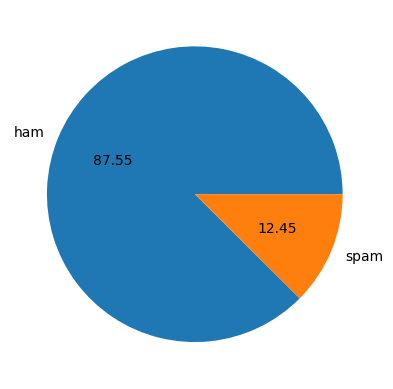

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

The dataset is imbalanced, which can affect the performance of machine learning models, as they may become biased towards the majority class.

In [17]:
%pip install -q nltk

In [18]:
import nltk

In [19]:
nltk.download('punkt') # punkt is pre-trained, unsupervised machine learning model used to detect sentence boundary.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
# create column to store the num_characters in sentences
df['num_characters'] = df['text'].apply(len)
df.sample(5)


,label,text,num_characters
83,0,You will be in the place of that man,36
2802,1,FreeMsg>FAV XMAS TONES!Reply REAL,33
4123,0,"Hey sexy buns ! Have I told you ? I adore you,...",153
1834,0,I have a rather prominent bite mark on my righ...,53
4453,0,I'm home. Ard wat time will u reach?,36


In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
# create column to store the num_words in sentences
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.sample(5)

,label,text,num_characters,num_words
906,1,"all the lastest from Stereophonics, Marley, Di...",162,32
501,0,When can Ì_ come out?,21,6
51,0,"A gram usually runs like <#> , a half eighth ...",112,27
3301,0,Stop calling everyone saying I might have canc...,165,35
1314,0,Got but got 2 colours lor. One colour is quite...,122,30


In [23]:
# create column to store the num_sentences for each entry
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.sample(5)

,label,text,num_characters,num_words,num_sentences
4377,0,"Doing nothing, then u not having dinner w us?",45,11,1
5028,1,I'd like to tell you my deepest darkest fantas...,126,26,3
336,0,Cool. So how come you havent been wined and di...,57,13,2
3895,1,tells u 2 call 09066358152 to claim å£5000 pri...,121,26,3
1773,0,"I'm not coming over, do whatever you want",41,10,1


In [24]:
# descriptive statistics on newly derived features
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5158.000000,5158.000000,5158.000000
mean,78.967623,18.325320,1.968592
std,57.950360,12.951979,1.453494
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,196.000000,38.000000


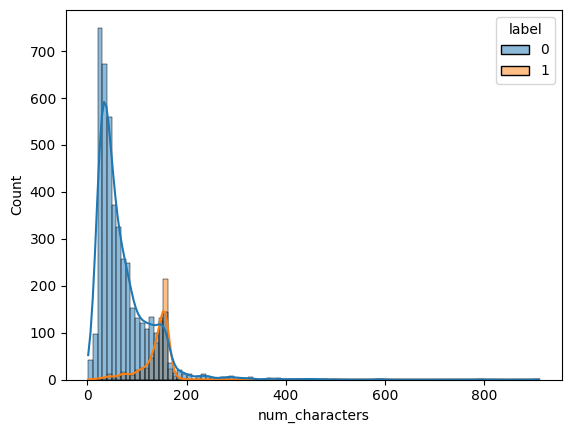

In [25]:
# plot combined histogram for different classes in label column for descriptive statistics
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='num_characters', hue='label', kde=True)
plt.show()

### Spam signature analysis

Spam messages often exhibit unique stylometric signatures such as digit density (phone numbers, shortcodes, claim codes, monetary amounts), currency symbols (e.g., `£`, `$`, `€`, `¥`, `₹`) advertising cash prizes and web urls for phishing and redirects etc. 

These features can be leveraged to improve the accuracy of spam detection models.

In [26]:
import re

# Extract spam signature features
df['digit_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))

df['currency_count'] = df['text'].apply(lambda x: len(re.findall(r'[\$£€¥₹]', x)))

df['uppercase_chars'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))

df['uppercase_words'] = df['text'].apply(lambda x: len([w for w in x.split() if w.isupper() and len(w) > 1]))

df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'https?://\S+|www\.\S+', x)))

# Display sample with new spam signature features
df[['text', 'digit_count', 'currency_count', 'uppercase_words', 'url_count', 'label']].sample(5)

,text,digit_count,currency_count,uppercase_words,url_count,label
4762,Prepare to be pleasured :),0,0,0,0,0
520,But that's on ebay it might be less elsewhere.,0,0,0,0,0
3247,Also track down any lighters you can find,0,0,0,0,0
4596,Full heat pa:-) i have applyed oil pa.,0,0,0,0,0
4351,Hows the pain dear?y r u smiling?,0,0,0,0,0


In [27]:
# Comparative statistical summary between Ham and Spam
signature_features = ['num_characters', 'digit_count', 'currency_count', 'uppercase_chars', 
                      'uppercase_words', 'url_count']

mean_comparison = df.groupby('label')[signature_features].mean().T
mean_comparison.columns = ['Ham', 'Spam']
mean_comparison['Spam / Ham Ratio'] = mean_comparison['Spam'] / (mean_comparison['Ham'] + 1e-5)
display(mean_comparison)

,Ham,Spam,Spam / Ham Ratio
num_characters,70.593003,137.876947,1.953125
digit_count,0.296723,15.442368,52.041330
currency_count,0.005314,0.415888,78.109255
uppercase_chars,4.049380,15.168224,3.745805
uppercase_words,0.461692,2.323988,5.033525
url_count,0.000221,0.133956,578.808068


## Data Preprocessing


In [30]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [31]:
import string
import html
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
# Convert stopwords list to a set ONCE for O(1) constant time lookups
stop_words = set(stopwords.words('english'))

def transform_text(text):
    # Null and type safety check
    if not text or not isinstance(text, str):
        return ""
    
    # Decode HTML entities and lowercase
    text = html.unescape(text).lower()

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Filter alphanumeric tokens
    tokens = [word for word in tokens if word.isalnum()]

    # Remove stopwords & punctuation via list comprehension (BUG FIX)
    tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

    # Apply Porter stemming
    tokens = [ps.stem(word) for word in tokens]

    return ' '.join(tokens)

In [32]:
# create a column transform_text to store the text after data proprocessing
df['transform_text'] = df['text'].apply(transform_text)
df.sample(5)

,label,text,num_characters,num_words,num_sentences,digit_count,currency_count,uppercase_chars,uppercase_words,url_count,transform_text
3477,0,I can ask around but there's not a lot in term...,63,16,1,0,0,1,0,0,ask around lot term mid
3512,0,Staff of placement training in Amrita college.,46,8,1,0,0,2,0,0,staff placement train amrita colleg
2896,0,ÌÏ collecting ur laptop then going to configur...,66,12,1,0,0,2,1,0,ìï collect ur laptop go configur da set izzit
224,1,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA...",143,27,2,31,1,20,4,1,500 new mobil 2004 must go txt nokia 89545 col...
1798,0,That one week leave i put know that time. Why.,46,12,2,0,0,2,0,0,one week leav put know time


In [33]:
# create word cloud for different classes of label feature
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

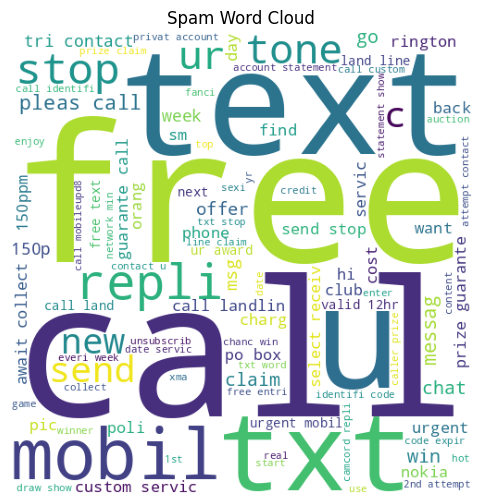

In [34]:
spam_wc = wc.generate(df[df['label']==1]['transform_text'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title('Spam Word Cloud')
plt.axis('off')
plt.show()

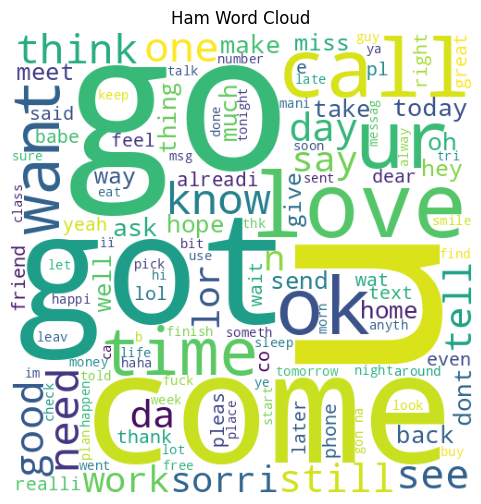

In [35]:
ham_wc = wc.generate(df[df['label']==0]['transform_text'].str.cat(sep=' '))

plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title('Ham Word Cloud')
plt.axis('off')
plt.show()

## Model Building and Experiments

### Text Representation Benchmark
We evaluate different vectorizer configurations using **Multinomial Naive Bayes** as a baseline to determine the best representation.

In [39]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Raw stratified train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['transform_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# Benchmark different vectorizers
vectorizers = {
    'CountVec (Unigram)': CountVectorizer(),
    'CountVec (Binary)': CountVectorizer(binary=True),
    'TF-IDF (Unigram)': TfidfVectorizer(max_features=3000),
    'TF-IDF (Unigram and Bigram)': TfidfVectorizer(ngram_range=(1, 2), max_features=3000),
    'TF-IDF (Full Vocab, Unigram)': TfidfVectorizer()
}

rep_results = []
for name, vec in vectorizers.items():
    X_tr = vec.fit_transform(X_train_raw)
    X_te = vec.transform(X_test_raw)
    
    clf = MultinomialNB()
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    
    rep_results.append({
        'Vectorizer': name,
        'Vocab Size': X_tr.shape[1],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_rep = pd.DataFrame(rep_results)
display(df_rep)

,Vectorizer,Vocab Size,Accuracy,Precision,Recall,F1-Score
0,CountVec (Unigram),5952,0.978682,0.934426,0.890625,0.912000
1,CountVec (Binary),5952,0.976744,0.933333,0.875000,0.903226
2,TF-IDF (Unigram),3000,0.967054,0.979592,0.750000,0.849558
3,TF-IDF (Unigram and Bigram),3000,0.968992,0.980000,0.765625,0.859649
4,"TF-IDF (Full Vocab, Unigram)",5952,0.960271,0.988764,0.687500,0.811060


### Feature Vectorization with Optimal TF-IDF

Based on the above experiments, **TF-IDF with Unigram and Bigram** yields the highest precision 98% and captures multi-word spam cues (e.g. `'free entry'`, `'call now'`).

In [40]:
# Vectorize using optimal TF-IDF configuration
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X = tfidf.fit_transform(df['transform_text']).toarray()
y = df['label'].values

# Stratified Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Train Class Balance: Ham={sum(y_train==0)}, Spam={sum(y_train==1)}")
print(f"Test Class Balance: Ham={sum(y_test==0)}, Spam={sum(y_test==1)}")

X_train shape: (4126, 3000) | X_test shape: (1032, 3000)
Train Class Balance: Ham=3612, Spam=514
Test Class Balance: Ham=904, Spam=128


### Multi-Model Classifier Benchmark

In [41]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Bernoulli Naive Bayes': BernoulliNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Linear SVC': LinearSVC(random_state=42),
    'SVC (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
}

model_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    model_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_models = pd.DataFrame(model_results).sort_values(by=['Precision', 'F1-Score'], ascending=False)
display(df_models)

,Model,Accuracy,Precision,Recall,F1-Score
4,SVC (RBF Kernel),0.981589,1.000000,0.851562,0.919831
2,Logistic Regression,0.962209,1.000000,0.695312,0.820276
1,Bernoulli Naive Bayes,0.978682,0.990741,0.835938,0.906780
3,Linear SVC,0.983527,0.982609,0.882812,0.930041
0,Multinomial Naive Bayes,0.970930,0.980392,0.781250,0.869565


### Voting Ensemble Classifier

To combine the strengths of top individual models, we construct a **Voting Classifier** (combining MultinomialNB, LinearSVC and Logistic Regression).

Voting Classifier classification report
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       904
        Spam       1.00      0.80      0.89       128

    accuracy                           0.98      1032
   macro avg       0.99      0.90      0.94      1032
weighted avg       0.98      0.98      0.97      1032



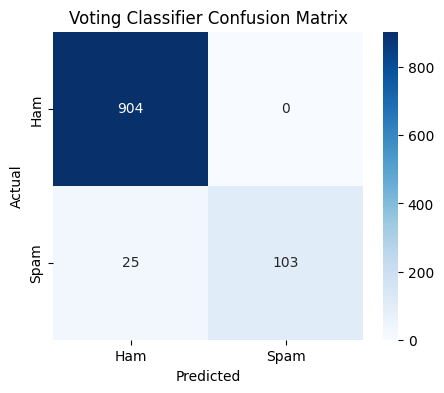

In [46]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize top individual models
clf_mnb = MultinomialNB()
clf_svc = LinearSVC(random_state=42)
clf_lr = LogisticRegression(random_state=42)
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('mnb', clf_mnb),
        ('svc', clf_svc),
        ('lr', clf_lr)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)

print("Voting Classifier classification report")
print(classification_report(y_test, y_pred_vote, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_vote)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Voting Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### TF-IDF or Hybrid Feature Model?


While TF-IDF captures lexical vocabulary, spam messages frequently exhibit strong structural and stylometric cues (high digit density, currency symbols, embedded URLs).

Here, we construct a **Hybrid Multi-Modal Feature Matrix** combining the TF-IDF features with normalized stylometric features using `MinMaxScaler` and `scipy.sparse.hstack`.

In [47]:
from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler
import re

# Extract Stylometric Signatures from the raw text
def extract_stylometric_matrix(df_subset):
    feat = pd.DataFrame()
    feat['num_characters'] = df_subset['text'].apply(len)
    feat['num_words'] = df_subset['text'].apply(lambda x: len(x.split()))
    feat['digit_count'] = df_subset['text'].apply(lambda x: sum(1 for c in x if c.isdigit()))
    feat['currency_count'] = df_subset['text'].apply(lambda x: len(re.findall(r'[\$£€¥₹]', x)))
    feat['uppercase_chars'] = df_subset['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
    feat['uppercase_words'] = df_subset['text'].apply(lambda x: len([w for w in x.split() if w.isupper() and len(w) > 1]))
    feat['url_count'] = df_subset['text'].apply(lambda x: len(re.findall(r'https?://\S+|www\.\S+', x)))
    return feat

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# TF-IDF Features
tfidf_hybrid = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_train_tfidf = tfidf_hybrid.fit_transform(train_df['transform_text'])
X_test_tfidf = tfidf_hybrid.transform(test_df['transform_text'])

# Stylometric features and MinMax scaling
scaler = MinMaxScaler()
X_train_stylometric = scaler.fit_transform(extract_stylometric_matrix(train_df))
X_test_stylometric = scaler.transform(extract_stylometric_matrix(test_df))

# Concatenate sparse TF-IDF with scaled Stylometric features
X_train_hybrid = hstack([X_train_tfidf, X_train_stylometric]).tocsr()
X_test_hybrid = hstack([X_test_tfidf, X_test_stylometric]).tocsr()

y_train_hybrid = train_df['label'].values
y_test_hybrid = test_df['label'].values

print(f"TF-IDF Feature Space Shape: {X_train_tfidf.shape}")
print(f"Stylometric Feature Space Shape: {X_train_stylometric.shape}")
print(f"Combined Hybrid Feature Space Shape: {X_train_hybrid.shape}")

TF-IDF Feature Space Shape: (4126, 3000)
Stylometric Feature Space Shape: (4126, 7)
Combined Hybrid Feature Space Shape: (4126, 3007)


In [48]:
# Benchmark Models on TF-IDF Only vs. Hybrid Features
eval_models = {
    'Linear SVC': LinearSVC(random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
}

hybrid_comparison = []

for name, clf in eval_models.items():
    # Evaluate on TF-IDF only
    clf.fit(X_train_tfidf, y_train_hybrid)
    y_pred_tfidf = clf.predict(X_test_tfidf)
    
    hybrid_comparison.append({
        'Model': name,
        'Feature Space': 'TF-IDF only',
        'Accuracy': accuracy_score(y_test_hybrid, y_pred_tfidf),
        'Precision': precision_score(y_test_hybrid, y_pred_tfidf),
        'Recall': recall_score(y_test_hybrid, y_pred_tfidf),
        'F1-Score': f1_score(y_test_hybrid, y_pred_tfidf)
    })
    
    # Evaluate on Hybrid (TF-IDF and Stylometric)
    clf.fit(X_train_hybrid, y_train_hybrid)
    y_pred_hyb = clf.predict(X_test_hybrid)
    
    hybrid_comparison.append({
        'Model': name,
        'Feature Space': 'Hybrid',
        'Accuracy': accuracy_score(y_test_hybrid, y_pred_hyb),
        'Precision': precision_score(y_test_hybrid, y_pred_hyb),
        'Recall': recall_score(y_test_hybrid, y_pred_hyb),
        'F1-Score': f1_score(y_test_hybrid, y_pred_hyb)
    })

df_hybrid_comp = pd.DataFrame(hybrid_comparison)
display(df_hybrid_comp)

,Model,Feature Space,Accuracy,Precision,Recall,F1-Score
0,Linear SVC,TF-IDF only,0.982558,0.974138,0.882812,0.926230
1,Linear SVC,Hybrid,0.987403,0.983193,0.914062,0.947368
2,Multinomial Naive Bayes,TF-IDF only,0.968992,0.980000,0.765625,0.859649
3,Multinomial Naive Bayes,Hybrid,0.978682,0.981818,0.843750,0.907563
4,Logistic Regression,TF-IDF only,0.968023,0.989691,0.750000,0.853333
5,Logistic Regression,Hybrid,0.978682,0.981818,0.843750,0.907563


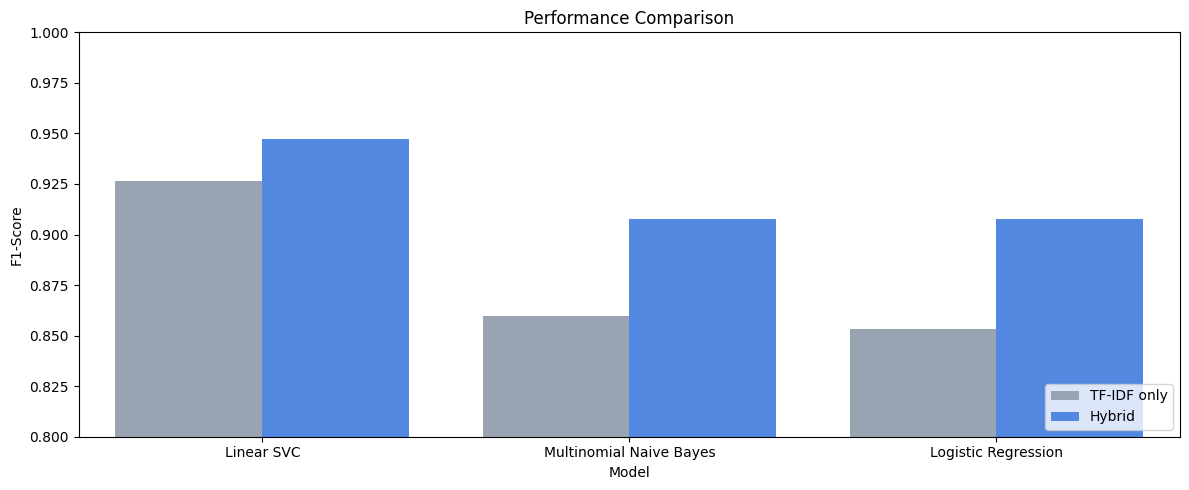

In [52]:
# Visualizing F1-Score improvement with Stylometric features
plt.figure(figsize=(12, 5))
sns.barplot(data=df_hybrid_comp, x='Model', y='F1-Score', hue='Feature Space', palette=['#94a3b8', '#3b82f6'])
plt.title('Performance Comparison')
plt.ylim(0.8, 1.0)
plt.ylabel('F1-Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [54]:
import joblib
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Multinomial Naive Bayes model
mnb_model = MultinomialNB(alpha=0.2)
mnb_model.fit(X_train, y_train)
joblib.dump(mnb_model, 'mnb_model.pkl')

# Linear SVC model 
linear_svc = CalibratedClassifierCV(LinearSVC(random_state=42), cv=5)
linear_svc.fit(X_train, y_train)
joblib.dump(linear_svc, 'linear_svc_model.pkl')

# 3TfidfVectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Models serialized and exported successfully:")
print(" - mnb_model.pkl (Tuned MultinomialNB)")
print(" - linear_svc_model.pkl (Calibrated LinearSVC)")
print(" - tfidf_vectorizer.pkl (TF-IDF Vectorizer)")

Models serialized and exported successfully:
 - mnb_model.pkl (Tuned MultinomialNB)
 - linear_svc_model.pkl (Calibrated LinearSVC)
 - tfidf_vectorizer.pkl (TF-IDF Vectorizer)
